## imports

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

import tidy3d as td
from tidy3d.constants import C_0
from tidy3d.plugins.mode import ModeSolver

## folders (timestamped run)

In [43]:
# root project structure
root = Path.cwd().parents[1]

data_root = root / "waveguide_design" / "data" / "raw"

run_name = datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = data_root / f"run_{run_name}"

plot_dir = run_dir / "plots"
field_dir = run_dir / "fields"

for d in [run_dir, plot_dir, field_dir]:
    d.mkdir(parents=True, exist_ok=True)

print("Run directory:", run_dir)

Run directory: c:\Users\Amirali\Desktop\Flexcompute Hackathon\waveguide_design\data\raw\run_20260501_234527


## settings

In [ ]:
settings = {
    "lambda_min_nm": 1500,
    "lambda_max_nm": 1600,
    "lambda0_um": 1.55,

    "wg_width_um": 1.0,
    "wg_thickness_um": 0.350,

    # Simulation domain size
    "x_span_um": 10.0,
    "y_span_um": 10.0,
    "z_span_um": 0.5,

    # Grid control
    "use_auto_grid": True,
    "min_steps_per_wvl": 20,

    # Local fine mesh override around waveguide
    "use_mesh_override": True,
    "mesh_override_x_span_um": 2.0,
    "mesh_override_y_span_um": 1.0,
    "mesh_override_z_span_um": 0.5,
    "mesh_override_dl_x_um": 0.01,
    "mesh_override_dl_y_um": 0.01,
    "mesh_override_dl_z_um": 0.05,

    # Used only if use_auto_grid = False
    "uniform_grid_um": 0.1,

    # PML
    "use_custom_pml_layers": True,
    "pml_num_layers": 12,

    # Modes
    "num_modes": 8,
}

## Material Dispersion Models

We use analytic refractive index models for silicon nitride (SiN) and silicon dioxide (SiO$_2$), given by:

### Silicon Nitride (SiN)

$$
n_{\mathrm{SiN}}^2(\lambda) =
1 + \frac{B_1 \lambda^2}{\lambda^2 - C_1^2} - D \lambda^2
$$

where

$$
B_1 = 2.938, \quad C_1 = 0.13372, \quad D = 0.02573
$$

and $\lambda$ is in $\mu\mathrm{m}$.

---

### Silicon Dioxide (SiO$_2$)

$$
n_{\mathrm{SiO_2}}^2(\lambda) =
1 + \frac{B_1 \lambda^2}{10^6 \lambda^2 - C_1^2}
$$

where

$$
B_1 = 1.09877 \times 10^6, \quad C_1 = 92.439
$$

---

## Derived Quantities

### Permittivity

$$
\epsilon(\lambda) = n^2(\lambda)
$$

---

### Group Index

The group index is defined as:

$$
n_g(\lambda) = n(\lambda) - \lambda \frac{dn}{d\lambda}
$$

In the implementation, the derivative is computed numerically:

$$
\frac{dn}{d\lambda} \approx \frac{d n}{d \lambda}
$$

---

## Wavelength Range

All quantities are evaluated over:

$$
1500 \ \mathrm{nm} \leq \lambda \leq 1600 \ \mathrm{nm}
$$

In [45]:
def n_sin(lambda_um):
    B1 = 2.938
    C1 = 0.13372
    D = 0.02573

    lam2 = lambda_um**2
    return np.sqrt(1 + (B1 * lam2) / (lam2 - C1**2) - D * lam2)


def n_sio2(lambda_um):
    B1 = 1.09877e6
    C1 = 92.439

    lam2 = lambda_um**2
    return np.sqrt(1 + (B1 * lam2) / (1e6 * lam2 - C1**2))

## dispersion + group index + epsilon

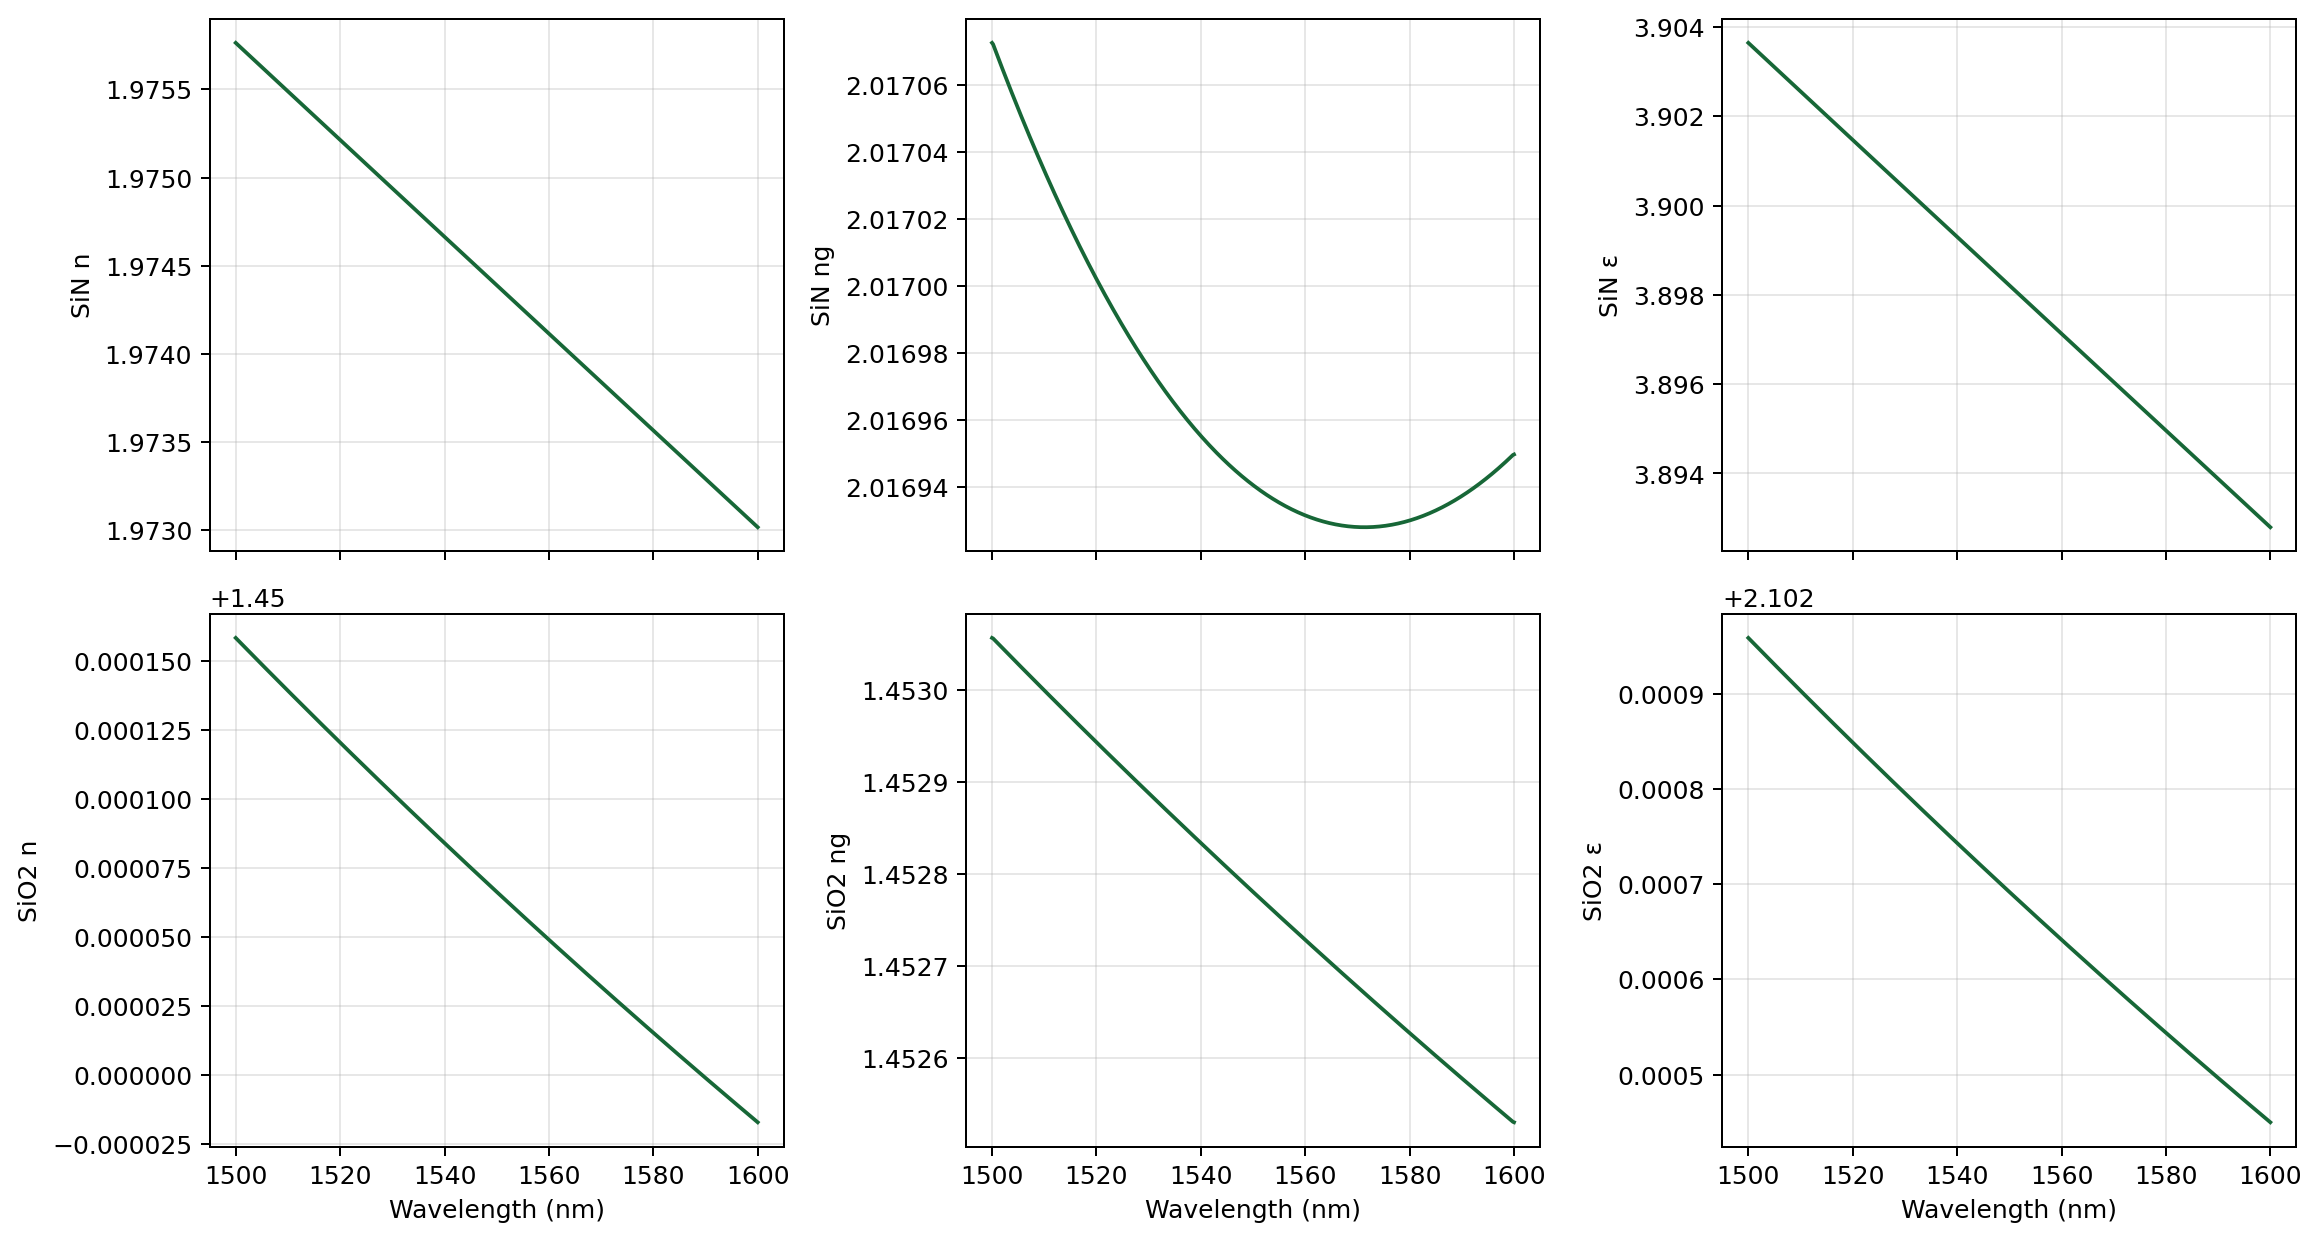

In [46]:
lambda_nm_dense = np.linspace(
    settings["lambda_min_nm"],
    settings["lambda_max_nm"],
    501,
)

lambda_um_dense = lambda_nm_dense / 1000


def compute_material_curves(n_func):
    n = n_func(lambda_um_dense)

    dn_dlambda = np.gradient(n, lambda_nm_dense)
    ng = n - lambda_nm_dense * dn_dlambda

    eps = n**2

    return n, ng, eps


sin_n, sin_ng, sin_eps = compute_material_curves(n_sin)
sio2_n, sio2_ng, sio2_eps = compute_material_curves(n_sio2)

## plot material
fig, axes = plt.subplots(2, 3, figsize=(13, 7), dpi=180, sharex=True)

# SiN
axes[0, 0].plot(lambda_nm_dense, sin_n)
axes[0, 0].set_ylabel("SiN n")

axes[0, 1].plot(lambda_nm_dense, sin_ng)
axes[0, 1].set_ylabel("SiN ng")

axes[0, 2].plot(lambda_nm_dense, sin_eps)
axes[0, 2].set_ylabel("SiN ε")

# SiO2
axes[1, 0].plot(lambda_nm_dense, sio2_n)
axes[1, 0].set_ylabel("SiO2 n")

axes[1, 1].plot(lambda_nm_dense, sio2_ng)
axes[1, 1].set_ylabel("SiO2 ng")

axes[1, 2].plot(lambda_nm_dense, sio2_eps)
axes[1, 2].set_ylabel("SiO2 ε")

for ax in axes[-1, :]:
    ax.set_xlabel("Wavelength (nm)")

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(plot_dir / "materials.png")
plt.show()

# material at simulation frequency

In [47]:
lambda0_um = settings["lambda0_um"]

n_core = float(n_sin(lambda0_um))
n_clad = float(n_sio2(lambda0_um))

eps_core = n_core**2
eps_clad = n_clad**2

core_medium = td.Medium(permittivity=eps_core)
clad_medium = td.Medium(permittivity=eps_clad)

print(n_core, n_clad)

1.9743895853852584 1.450066185745872


## geometry

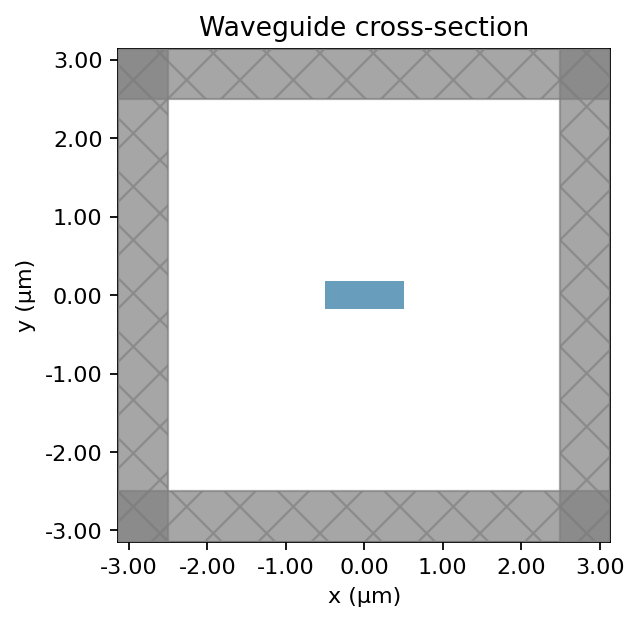

In [48]:
wg_width = settings["wg_width_um"]
wg_thick = settings["wg_thickness_um"]

lambda0_um = settings["lambda0_um"]
freq0 = C_0 / lambda0_um

waveguide = td.Structure(
    geometry=td.Box(
        center=(0, 0, 0),
        size=(wg_width, wg_thick, td.inf),
    ),
    medium=core_medium,
)

if settings["use_auto_grid"]:
    if settings["use_mesh_override"]:
        grid_spec = td.GridSpec.auto(
            wavelength=lambda0_um,  # IMPORTANT
            min_steps_per_wvl=settings["min_steps_per_wvl"],
            override_structures=[
                td.MeshOverrideStructure(
                    geometry=td.Box(
                        center=(0, 0, 0),
                        size=(
                            settings["mesh_override_x_span_um"],
                            settings["mesh_override_y_span_um"],
                            settings["mesh_override_z_span_um"],
                        ),
                    ),
                    dl=(
                        settings["mesh_override_dl_x_um"],
                        settings["mesh_override_dl_y_um"],
                        settings["mesh_override_dl_z_um"],
                    ),
                )
            ],
        )
    else:
        grid_spec = td.GridSpec.auto(
            wavelength=lambda0_um,  # IMPORTANT
            min_steps_per_wvl=settings["min_steps_per_wvl"],
        )
else:
    grid_spec = td.GridSpec.uniform(
        dl=settings["uniform_grid_um"],
    )

if settings["use_custom_pml_layers"]:
    boundary = td.PML(num_layers=settings["pml_num_layers"])
else:
    boundary = td.PML()

sim = td.Simulation(
    size=(
        settings["x_span_um"],
        settings["y_span_um"],
        settings["z_span_um"],
    ),
    grid_spec=grid_spec,
    structures=[waveguide],
    medium=clad_medium,
    boundary_spec=td.BoundarySpec.all_sides(boundary=boundary),
    run_time=1e-12,
)

plane = td.Box(
    center=(0, 0, 0),
    size=(
        settings["x_span_um"],
        settings["y_span_um"],
        0,
    ),
)

fig, ax = plt.subplots(figsize=(6, 4), dpi=160)
sim.plot(z=0, ax=ax)
ax.set_title("Waveguide cross-section")
plt.show()

## Mode Solver

In [49]:
mode_spec = td.ModeSpec(
    num_modes=settings["num_modes"],
    target_neff=n_core,
    group_index_step=True,
)

mode_solver = ModeSolver(
    simulation=sim,
    plane=plane,
    mode_spec=mode_spec,
    freqs=[freq0],
)

mode_data = mode_solver.solve()

neff_all = np.real(np.squeeze(mode_data.n_eff.values))
print("n_eff:", neff_all)

11:45:40 PM Eastern Daylight Time WARNING: Mode field at frequency index 0, mode
                                  index 2 does not decay at the plane           
                                  boundaries.                                   

                                  WARNING: Mode field at frequency index 0, mode
                                  index 3 does not decay at the plane           
                                  boundaries.                                   

                                  WARNING: Mode field at frequency index 0, mode
                                  index 4 does not decay at the plane           
                                  boundaries.                                   

                                  WARNING: Mode field at frequency index 0, mode
                                  index 5 does not decay at the plane           
                                  boundaries.                                   

                                  WARNING: Mode field at frequency index 1, mode
                                  index 2 does not decay at the plane           
                                  boundaries.                                   

...

                                  WARNING: Mode field at frequency index 2, mode
                                  index 2 does not decay at the plane           
                                  boundaries.                                   

                                  WARNING: Mode field at frequency index 2, mode
                                  index 3 does not decay at the plane           
                                  boundaries.                                   

                                  WARNING: Mode field at frequency index 2, mode
                                  index 4 does not decay at the plane           
                                  boundaries.                                   

                                  WARNING: Mode field at frequency index 2, mode
                                  index 5 does not decay at the plane           
                                  boundaries.                                   

n_eff: [1.59693661 1.53209021 1.43932376 1.4351038  1.43442635 1.43274502
 1.42380061 1.41957686]


## Helpers

In [50]:
def get_field(mode_data, name, i):
    return np.squeeze(
        getattr(mode_data, name).isel(mode_index=i, f=0).values
    )


def get_xy(mode_data):
    x = np.array(mode_data.Ex.coords["x"])
    y = np.array(mode_data.Ex.coords["y"])
    return x, y

## Mode Metrics

In [51]:
def compute_metrics(mode_data, i):
    x, y = get_xy(mode_data)
    X, Y = np.meshgrid(x, y, indexing="ij")

    Ex = get_field(mode_data, "Ex", i)
    Ey = get_field(mode_data, "Ey", i)
    Ez = get_field(mode_data, "Ez", i)

    I = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2

    dx = np.mean(np.diff(x))
    dy = np.mean(np.diff(y))
    dA = dx * dy

    P = np.sum(I) * dA

    xbar = np.sum(X * I) * dA / P
    ybar = np.sum(Y * I) * dA / P

    Aeff = P**2 / (np.sum(I**2) * dA)

    sx = np.sqrt(np.sum((X - xbar)**2 * I) * dA / P)
    sy = np.sqrt(np.sum((Y - ybar)**2 * I) * dA / P)

    mfd_x = 4 * sx
    mfd_y = 4 * sy

    TE_fraction = np.sum(np.abs(Ex)**2) / np.sum(
        np.abs(Ex)**2 + np.abs(Ey)**2
    )

    return Aeff, xbar, ybar, mfd_x, mfd_y, TE_fraction

## Field Plots

Guided modes: [0, 1]


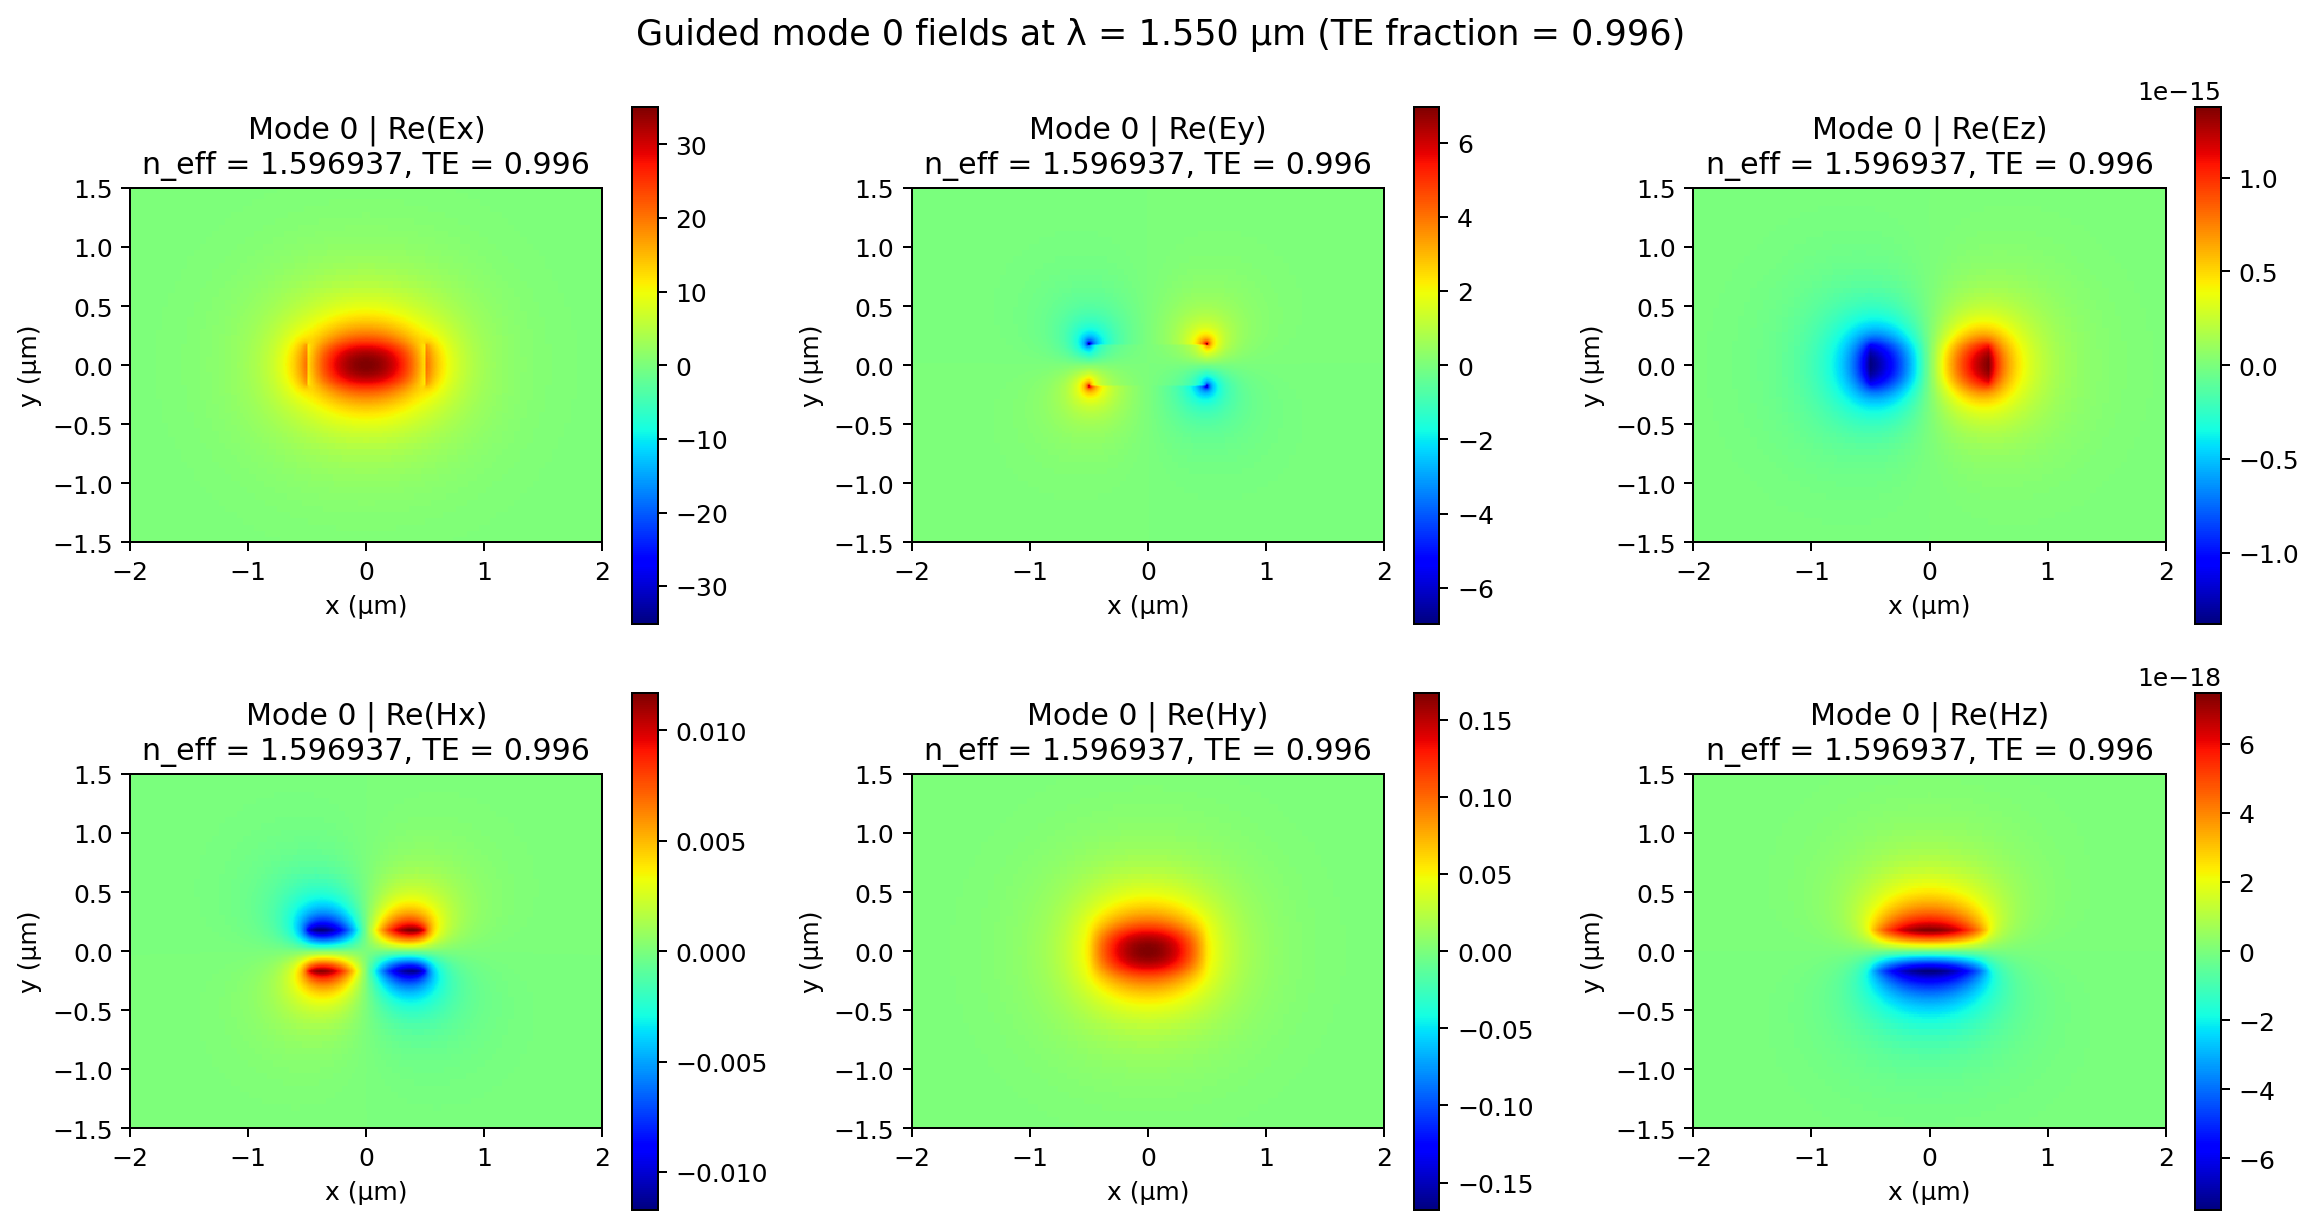

Saved: c:\Users\Amirali\Desktop\Flexcompute Hackathon\waveguide_design\data\raw\run_20260501_234527\plots\mode_00_fields.png


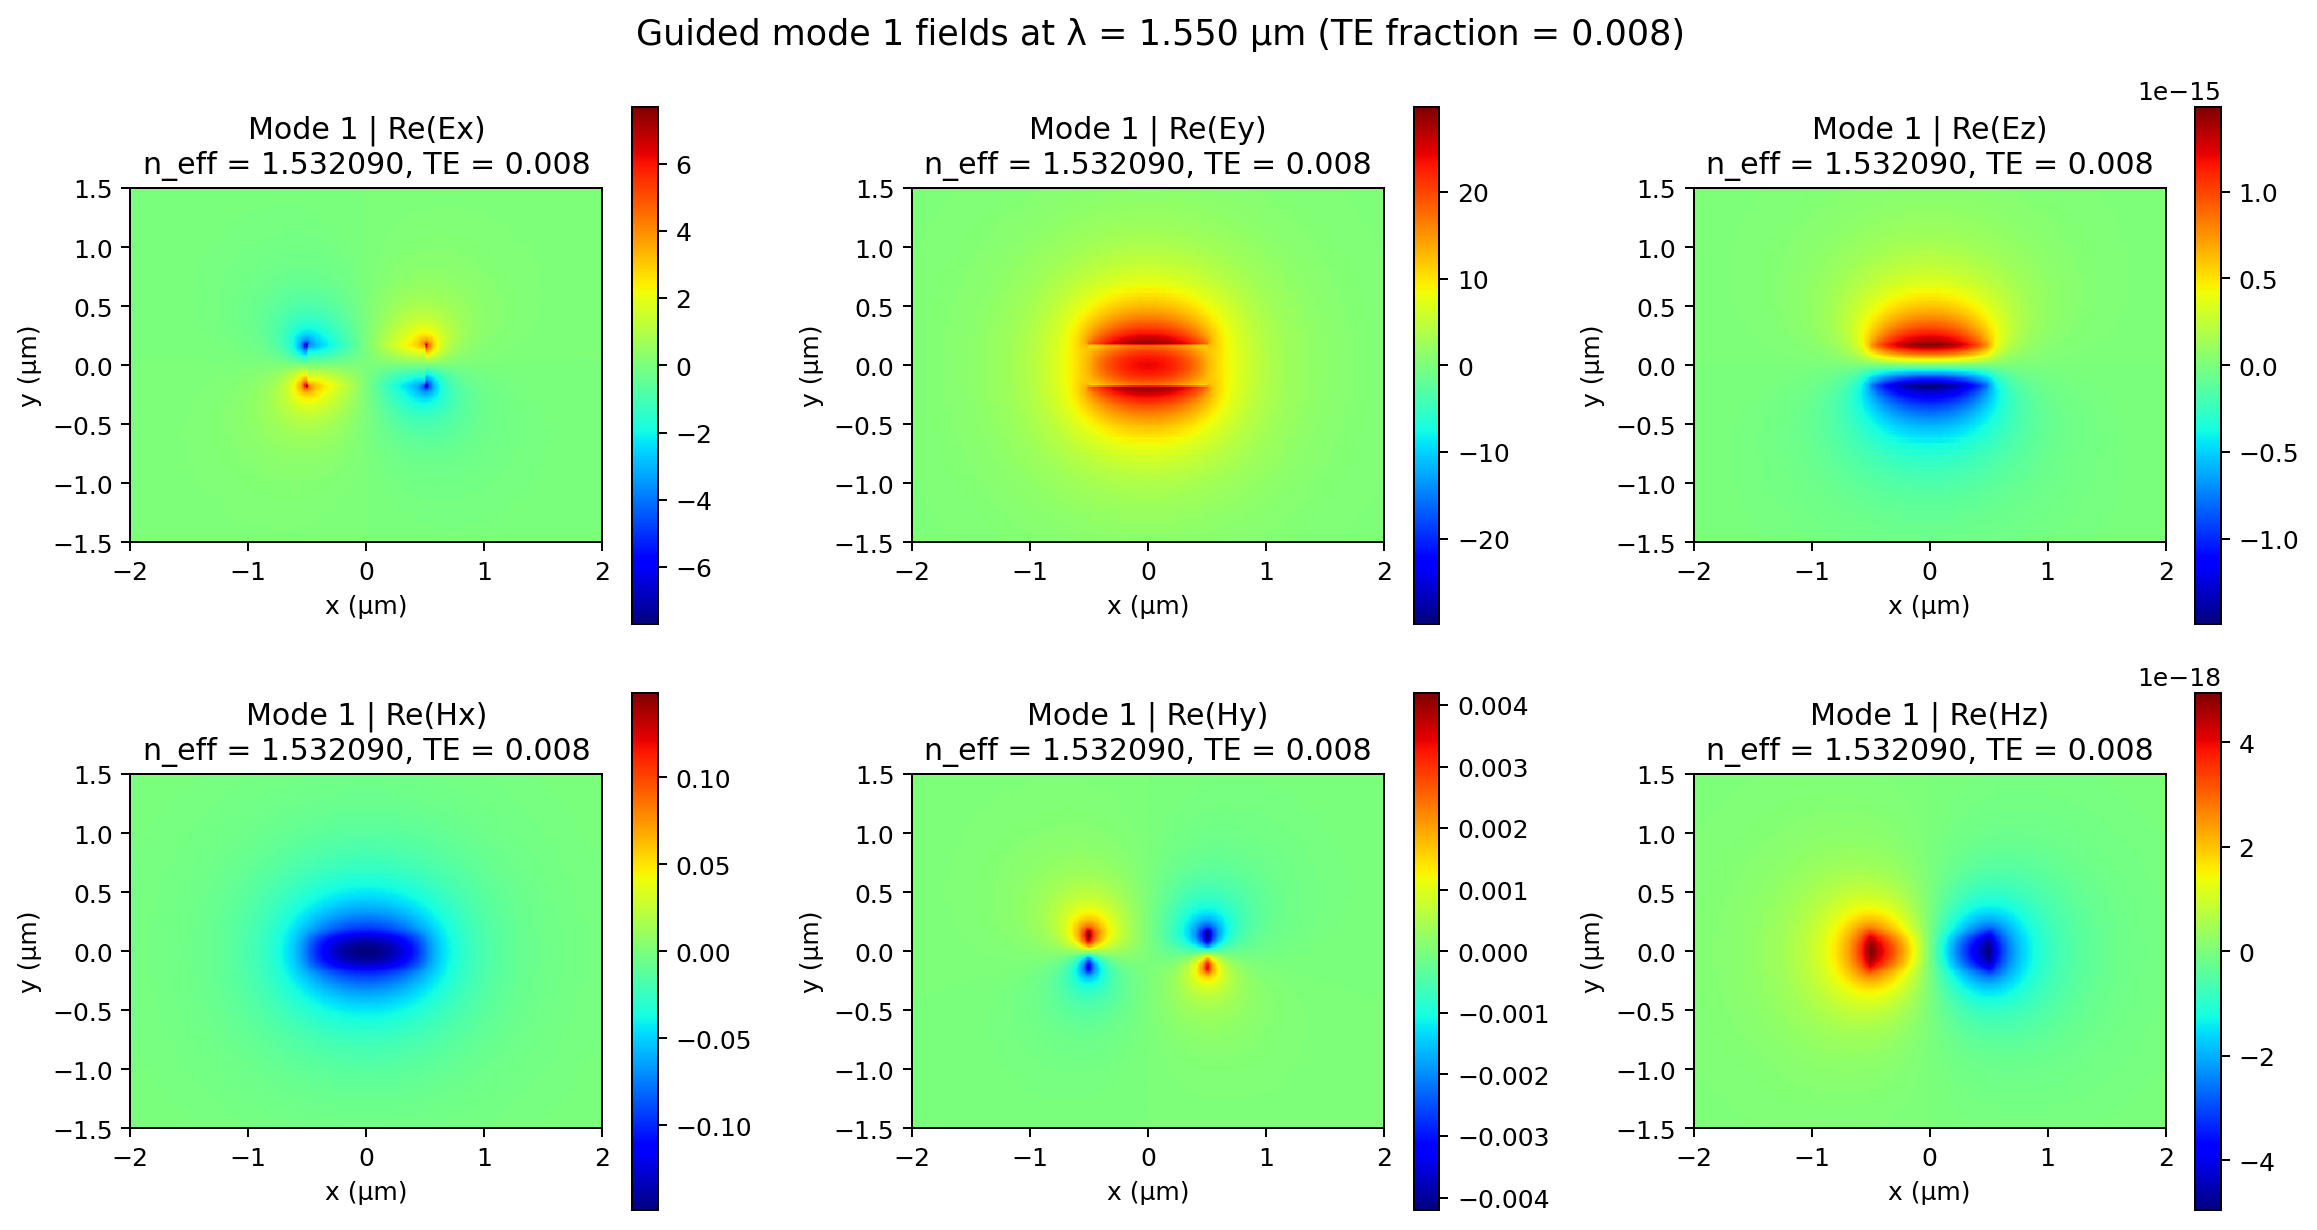

Saved: c:\Users\Amirali\Desktop\Flexcompute Hackathon\waveguide_design\data\raw\run_20260501_234527\plots\mode_01_fields.png


In [52]:
# ------------------------------------------------------------
# Field plots for all guided modes: Re(Ex,Ey,Ez), Re(Hx,Hy,Hz)
# Includes TE fraction in titles
# ------------------------------------------------------------

# Plot window settings
x_plot_min_um = -2.0
x_plot_max_um =  2.0
y_plot_min_um = -1.5
y_plot_max_um =  1.5

cmap_name = "jet"

x, y = get_xy(mode_data)

guided_mode_indices = [
    i for i, neff in enumerate(neff_all)
    if neff > n_clad
]

print("Guided modes:", guided_mode_indices)

field_names = [
    ["Ex", "Ey", "Ez"],
    ["Hx", "Hy", "Hz"],
]

for mode_i in guided_mode_indices:

    # ---- compute TE fraction once ----
    _, _, _, _, _, TE_frac = compute_metrics(mode_data, mode_i)

    fig, axes = plt.subplots(2, 3, figsize=(13, 7), dpi=180)

    for r in range(2):
        for c in range(3):
            field_name = field_names[r][c]
            data = np.real(get_field(mode_data, field_name, mode_i))

            vmax = np.nanmax(np.abs(data))
            vmin = -vmax

            im = axes[r, c].pcolormesh(
                x,
                y,
                data.T,
                shading="auto",
                cmap=cmap_name,
                vmin=vmin,
                vmax=vmax,
            )

            axes[r, c].set_title(
                f"Mode {mode_i} | Re({field_name})\n"
                f"n_eff = {neff_all[mode_i]:.6f}, TE = {TE_frac:.3f}"
            )

            axes[r, c].set_xlabel("x (µm)")
            axes[r, c].set_ylabel("y (µm)")
            axes[r, c].set_xlim(x_plot_min_um, x_plot_max_um)
            axes[r, c].set_ylim(y_plot_min_um, y_plot_max_um)
            axes[r, c].set_aspect("equal")

            fig.colorbar(im, ax=axes[r, c])

    fig.suptitle(
        f"Guided mode {mode_i} fields at λ = {lambda0_um:.3f} µm "
        f"(TE fraction = {TE_frac:.3f})",
        fontsize=14,
    )

    fig.tight_layout()

    save_path = plot_dir / f"mode_{mode_i:02d}_fields.png"
    fig.savefig(save_path, bbox_inches="tight")

    plt.show()

    print("Saved:", save_path)

## Index + Intensity + MFD + Cuts

Guided modes: [0, 1]


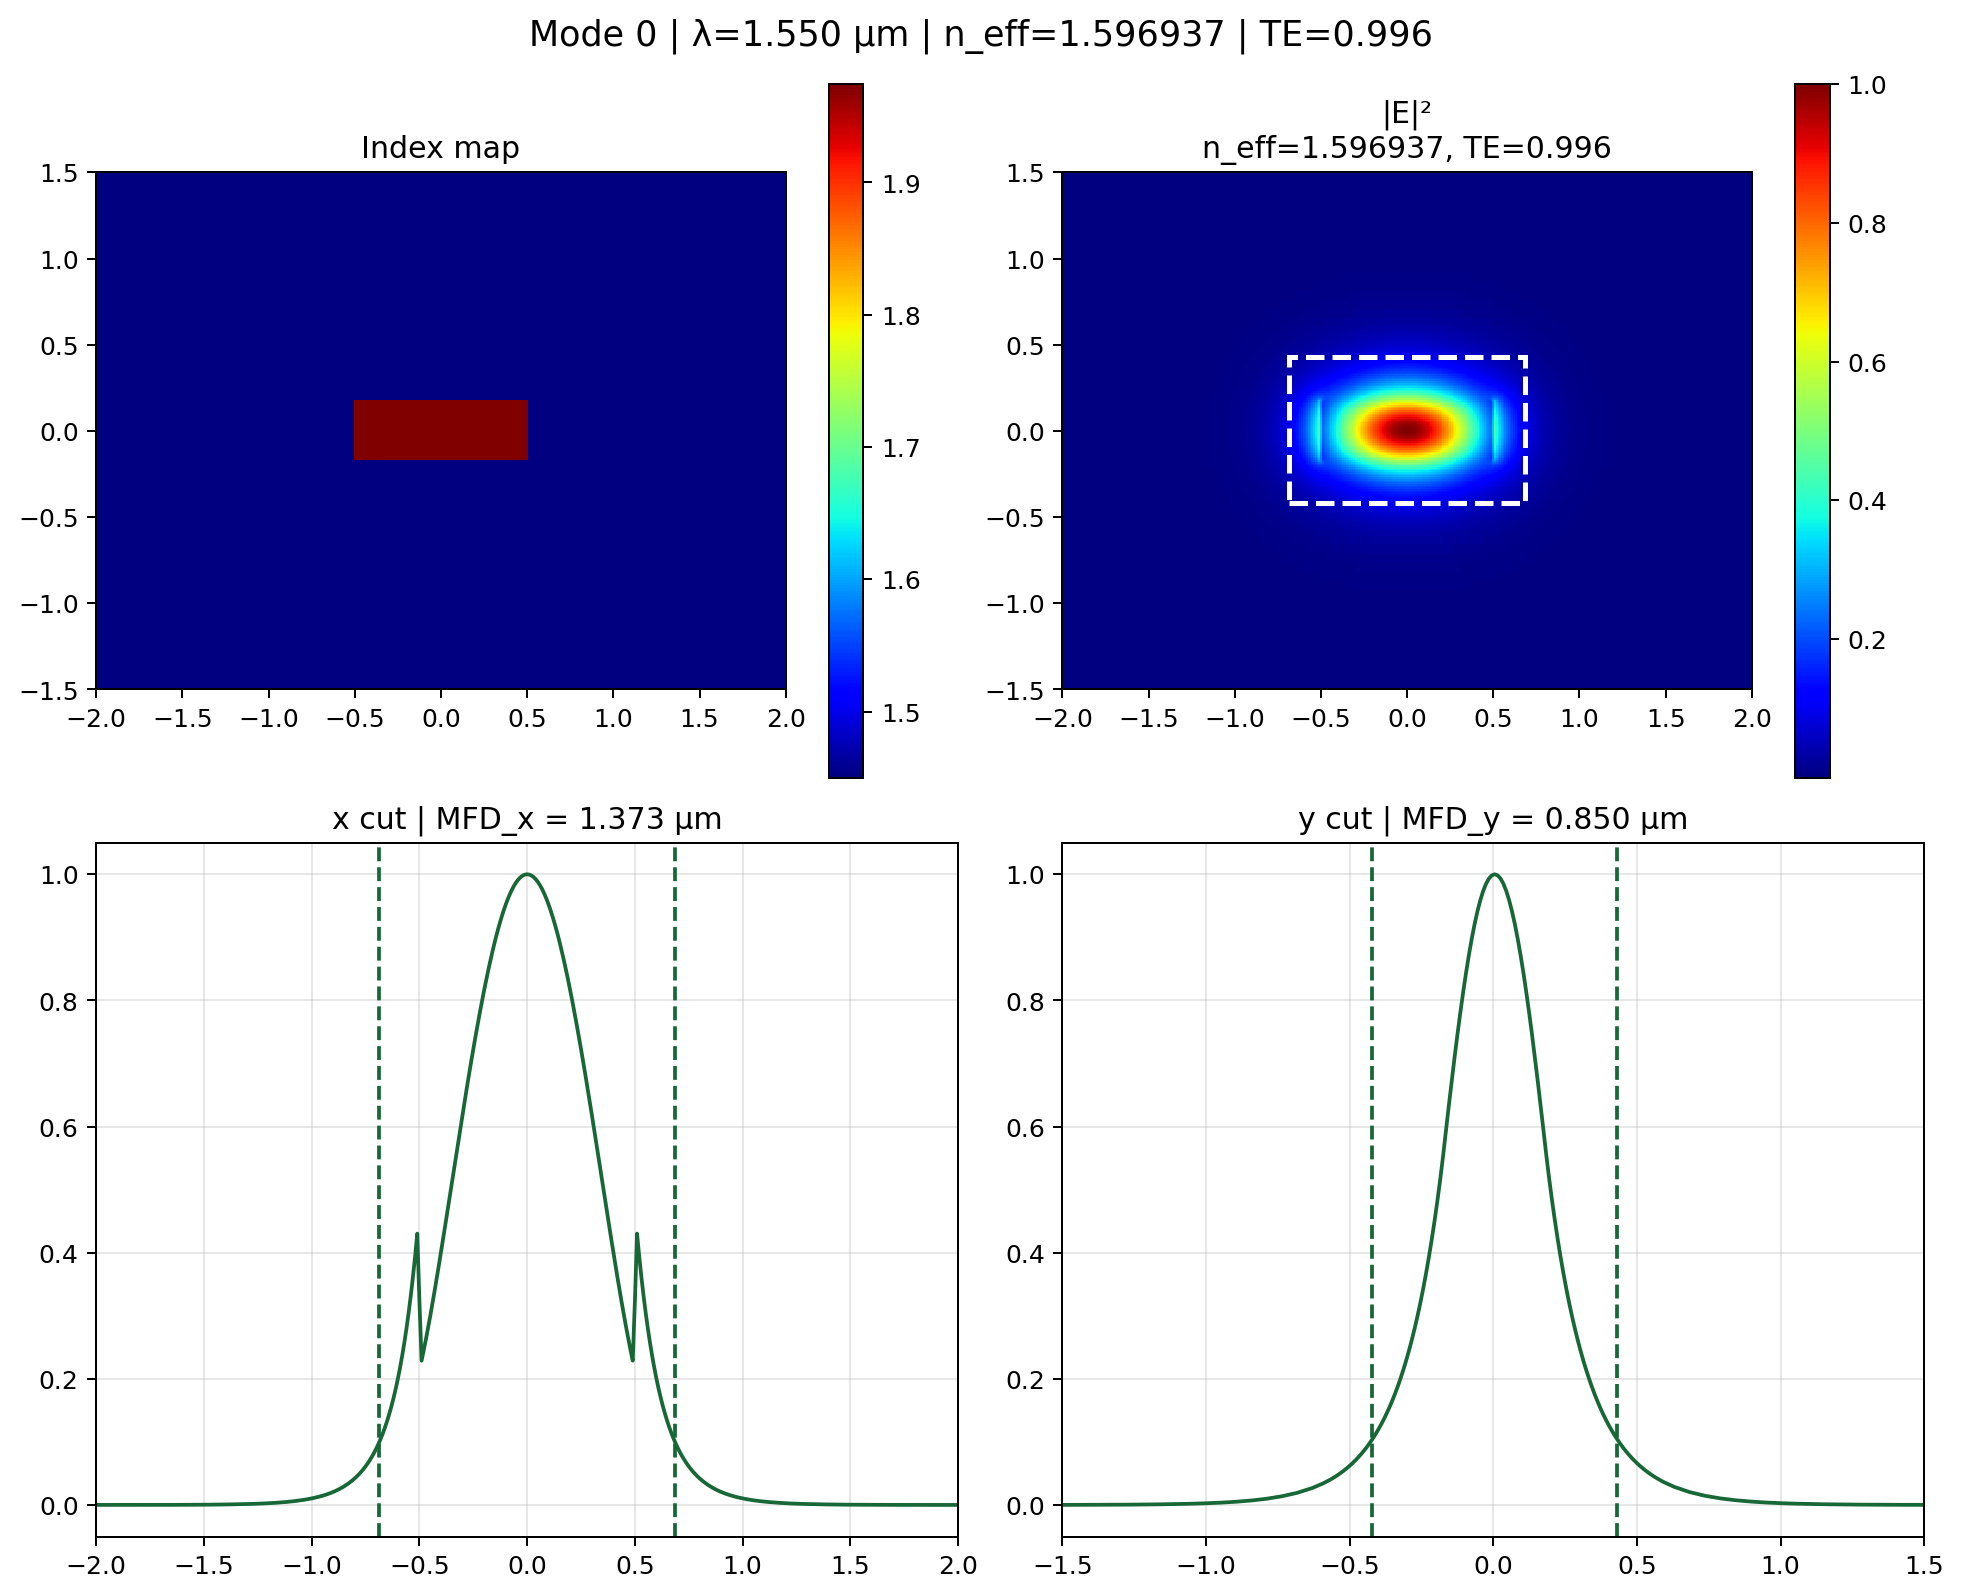

Saved: c:\Users\Amirali\Desktop\Flexcompute Hackathon\waveguide_design\data\raw\run_20260501_234527\plots\mode_00_intensity_analysis.png


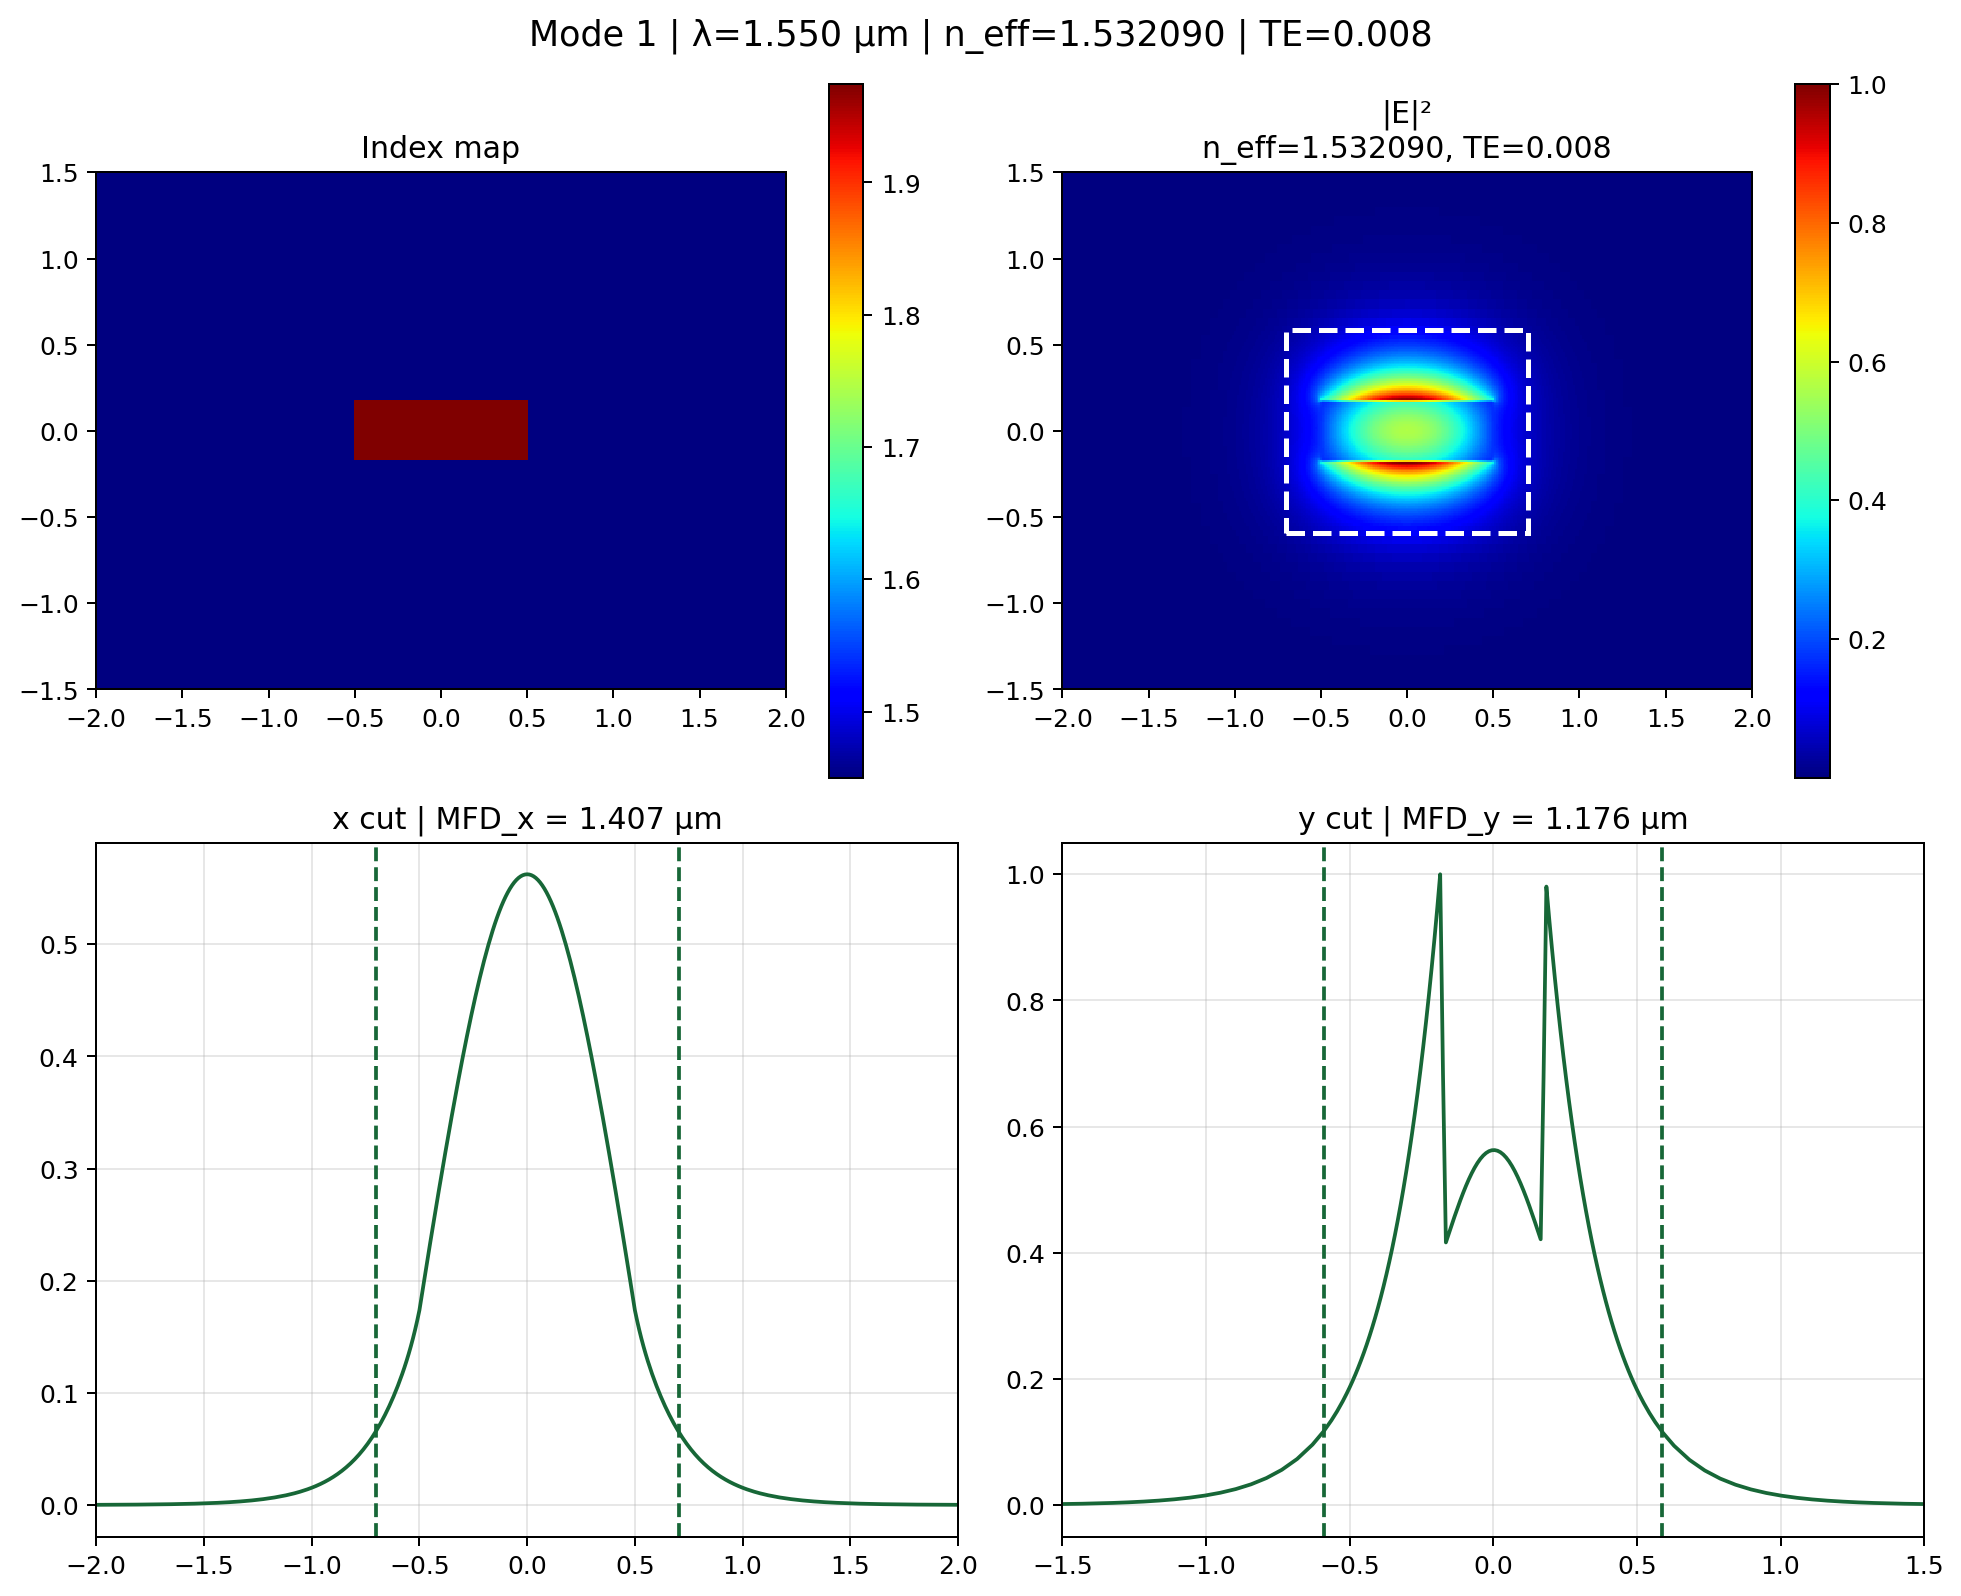

Saved: c:\Users\Amirali\Desktop\Flexcompute Hackathon\waveguide_design\data\raw\run_20260501_234527\plots\mode_01_intensity_analysis.png


In [53]:
# ------------------------------------------------------------
# Index + Intensity + MFD + Cuts for ALL guided modes
# ------------------------------------------------------------

# Plot window settings
x_plot_min_um = -2.0
x_plot_max_um =  2.0
y_plot_min_um = -1.5
y_plot_max_um =  1.5

cmap_name = "jet"

x, y = get_xy(mode_data)
X, Y = np.meshgrid(x, y, indexing="ij")

# index map
n_map = np.full_like(X, n_clad)
n_map[(np.abs(X) <= wg_width/2) & (np.abs(Y) <= wg_thick/2)] = n_core

guided_mode_indices = [
    i for i, neff in enumerate(neff_all)
    if neff > n_clad
]

print("Guided modes:", guided_mode_indices)

for mode_i in guided_mode_indices:

    # fields
    Ex = get_field(mode_data, "Ex", mode_i)
    Ey = get_field(mode_data, "Ey", mode_i)
    Ez = get_field(mode_data, "Ez", mode_i)

    I = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2
    I /= np.max(I)

    # metrics
    Aeff, xbar, ybar, mfdx, mfdy, TE_frac = compute_metrics(mode_data, mode_i)

    # cuts
    ix = np.argmin(np.abs(x - xbar))
    iy = np.argmin(np.abs(y - ybar))

    fig, ax = plt.subplots(2, 2, figsize=(11, 9), dpi=180)

    # ---- index ----
    im0 = ax[0, 0].pcolormesh(
        x, y, n_map.T, shading="auto", cmap=cmap_name
    )
    ax[0, 0].set_title("Index map")
    ax[0, 0].set_xlim(x_plot_min_um, x_plot_max_um)
    ax[0, 0].set_ylim(y_plot_min_um, y_plot_max_um)
    ax[0, 0].set_aspect("equal")
    fig.colorbar(im0, ax=ax[0, 0])

    # ---- intensity ----
    im1 = ax[0, 1].pcolormesh(
        x, y, I.T, shading="auto", cmap=cmap_name
    )

    ax[0, 1].add_patch(plt.Rectangle(
        (xbar - mfdx/2, ybar - mfdy/2),
        mfdx, mfdy,
        fill=False,
        lw=2,
        linestyle="--",   # dashed box
        color="white"
    ))

    ax[0, 1].set_title(
        f"|E|²\nn_eff={neff_all[mode_i]:.6f}, TE={TE_frac:.3f}"
    )
    ax[0, 1].set_xlim(x_plot_min_um, x_plot_max_um)
    ax[0, 1].set_ylim(y_plot_min_um, y_plot_max_um)
    ax[0, 1].set_aspect("equal")
    fig.colorbar(im1, ax=ax[0, 1])

    # ---- x cut ----
    ax[1, 0].plot(x, I[:, iy])
    ax[1, 0].axvline(xbar - mfdx/2, linestyle="--")
    ax[1, 0].axvline(xbar + mfdx/2, linestyle="--")
    ax[1, 0].set_title(f"x cut | MFD_x = {mfdx:.3f} µm")
    ax[1, 0].set_xlim(x_plot_min_um, x_plot_max_um)
    ax[1, 0].grid(True, alpha=0.3)

    # ---- y cut ----
    ax[1, 1].plot(y, I[ix, :])
    ax[1, 1].axvline(ybar - mfdy/2, linestyle="--")
    ax[1, 1].axvline(ybar + mfdy/2, linestyle="--")
    ax[1, 1].set_title(f"y cut | MFD_y = {mfdy:.3f} µm")
    ax[1, 1].set_xlim(y_plot_min_um, y_plot_max_um)
    ax[1, 1].grid(True, alpha=0.3)

    # ---- overall title ----
    fig.suptitle(
        f"Mode {mode_i} | λ={lambda0_um:.3f} µm | "
        f"n_eff={neff_all[mode_i]:.6f} | TE={TE_frac:.3f}",
        fontsize=14
    )

    plt.tight_layout()

    save_path = plot_dir / f"mode_{mode_i:02d}_intensity_analysis.png"
    fig.savefig(save_path, bbox_inches="tight")

    plt.show()

    print("Saved:", save_path)

## Save fields for all guided modes

In [54]:
# ------------------------------------------------------------
# Save field data for all guided modes
# ------------------------------------------------------------

x, y = get_xy(mode_data)

guided_mode_indices = [
    i for i, neff in enumerate(neff_all)
    if neff > n_clad
]

for mode_i in guided_mode_indices:

    fields = {}
    for name in ["Ex", "Ey", "Ez", "Hx", "Hy", "Hz"]:
        fields[name] = get_field(mode_data, name, mode_i)

    np.savez(
        field_dir / f"mode_{mode_i:02d}_fields.npz",
        x=x,
        y=y,
        mode_index=mode_i,
        wavelength_um=lambda0_um,
        n_eff=neff_all[mode_i],
        n_clad=n_clad,
        n_core=n_core,
        **fields,
    )

    print("Saved:", field_dir / f"mode_{mode_i:02d}_fields.npz")

Saved: c:\Users\Amirali\Desktop\Flexcompute Hackathon\waveguide_design\data\raw\run_20260501_234527\fields\mode_00_fields.npz
Saved: c:\Users\Amirali\Desktop\Flexcompute Hackathon\waveguide_design\data\raw\run_20260501_234527\fields\mode_01_fields.npz


## CSV for all guided modes

In [55]:
# ------------------------------------------------------------
# CSV summary for all guided modes
# ------------------------------------------------------------

rows = []

for mode_i, neff in enumerate(neff_all):

    if neff <= n_clad:
        continue

    Aeff, xbar, ybar, mfdx, mfdy, te = compute_metrics(mode_data, mode_i)

    if hasattr(mode_data, "n_group"):
        ng_all = np.real(np.squeeze(mode_data.n_group.values))
        ng = float(ng_all[mode_i])
    else:
        ng = np.nan

    rows.append({
        "mode": mode_i,
        "wavelength_um": lambda0_um,
        "width_um": wg_width,
        "thickness_um": wg_thick,

        "n_eff": float(neff),
        "n_g": ng,

        "mode_area_um2": float(Aeff),
        "xbar_um": float(xbar),
        "ybar_um": float(ybar),
        "mfd_x_um": float(mfdx),
        "mfd_y_um": float(mfdy),
        "TE_fraction": float(te),

        "n_core": float(n_core),
        "n_clad": float(n_clad),
    })

df = pd.DataFrame(rows)

csv_path = run_dir / "guided_modes.csv"
df.to_csv(csv_path, index=False)

df

,mode,wavelength_um,width_um,thickness_um,n_eff,n_g,mode_area_um2,xbar_um,ybar_um,mfd_x_um,mfd_y_um,TE_fraction,n_core,n_clad
0,0,1.55,1.0,0.35,1.596937,1.940778,4.472841,-5.807191e-15,0.004366,1.372935,0.849933,0.995992,1.97439,1.450066
1,1,1.55,1.0,0.35,1.532090,1.809522,6.337507,-4.904691e-14,-0.002015,1.407083,1.175761,0.007858,1.97439,1.450066


## Save settings

In [56]:
# ------------------------------------------------------------
# Save settings for reproducibility
# ------------------------------------------------------------

settings_path = run_dir / "settings.csv"

settings_df = pd.DataFrame(
    [{"key": k, "value": v} for k, v in settings.items()]
)

settings_df.to_csv(settings_path, index=False)

print("Saved settings:", settings_path)
print("Saved CSV:", csv_path)
print("Run directory:", run_dir)

Saved settings: c:\Users\Amirali\Desktop\Flexcompute Hackathon\waveguide_design\data\raw\run_20260501_234527\settings.csv
Saved CSV: c:\Users\Amirali\Desktop\Flexcompute Hackathon\waveguide_design\data\raw\run_20260501_234527\guided_modes.csv
Run directory: c:\Users\Amirali\Desktop\Flexcompute Hackathon\waveguide_design\data\raw\run_20260501_234527


## Final quick summary

In [57]:
# ------------------------------------------------------------
# Quick summary
# ------------------------------------------------------------

print("Number of guided modes:", len(df))
print()
print(df[[
    "mode",
    "n_eff",
    "n_g",
    "mode_area_um2",
    "mfd_x_um",
    "mfd_y_um",
    "TE_fraction",
]])

Number of guided modes: 2

   mode     n_eff       n_g  mode_area_um2  mfd_x_um  mfd_y_um  TE_fraction
0     0  1.596937  1.940778       4.472841  1.372935  0.849933     0.995992
1     1  1.532090  1.809522       6.337507  1.407083  1.175761     0.007858
